In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
df = df.drop(columns=['CustomerID'])

In [4]:
df.shape

(64374, 11)

In [5]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
 10  Churn              64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB


In [7]:
n = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = n[:-1]
numeric_cols

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction']

In [8]:
c = df.select_dtypes(exclude=['number']).columns.tolist()
cat_cols = c
cat_cols

['Gender', 'Subscription Type', 'Contract Length']

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
65-17

48

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,64374.0,41.970982,13.924911,18.0,30.0,42.0,54.0,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.0,33.0,47.0,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.0,7.0,15.0,23.0,30.0
Support Calls,64374.0,5.400690,3.114005,0.0,3.0,6.0,8.0,10.0
Payment Delay,64374.0,17.133952,8.852211,0.0,10.0,19.0,25.0,30.0
Total Spend,64374.0,541.023379,260.874809,100.0,313.0,534.0,768.0,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.0,8.0,15.0,23.0,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.0,0.0,1.0,1.0


<Axes: xlabel='Age', ylabel='Count'>

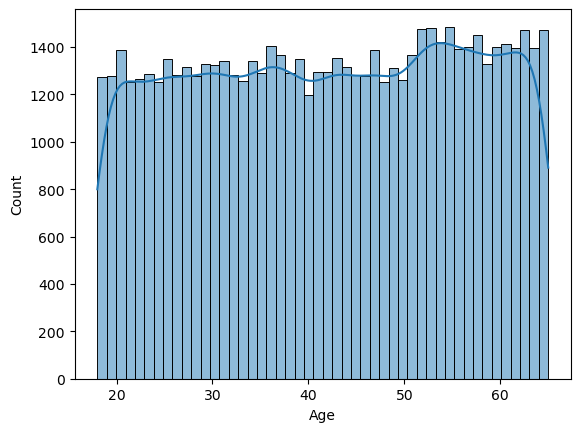

In [15]:
sns.histplot(data=df, x='Age', bins=48, kde=True)

In [14]:
import math
math.sqrt(64374)

253.72031846109604

In [16]:
# Create smarter behavioral columns
df['Spend_Per_Month'] = df['Total Spend'] / (df['Tenure'] + 1) # Adding 1 avoids division-by-zero errors for brand new users
df['Calls_Per_Month'] = df['Support Calls'] / (df['Tenure'] + 1)

In [17]:
import numpy as np

# Apply log transformation to smooth out the heavily skewed spend column
df['Log_Total_Spend'] = np.log1p(df['Total Spend']) # log1p handles log(0) safely if someone has zero spend

In [18]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [19]:
df

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Spend_Per_Month,Calls_Per_Month,Log_Total_Spend,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,23.000000,0.153846,6.395262,False,False,False,True,False
1,41,28,28,7,13,584,20,0,20.137931,0.241379,6.371612,False,False,True,True,False
2,47,27,10,2,29,757,21,0,27.035714,0.071429,6.630683,True,True,False,False,False
3,35,9,12,5,17,232,18,0,23.200000,0.500000,5.451038,True,True,False,False,True
4,53,58,24,9,2,533,18,0,9.033898,0.152542,6.280396,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64369,45,33,12,6,21,947,14,1,27.852941,0.176471,6.854355,False,False,False,False,True
64370,37,6,1,5,22,923,9,1,131.857143,0.714286,6.828712,True,False,True,False,False
64371,25,39,14,8,30,327,20,1,8.175000,0.200000,5.793014,True,True,False,True,False
64372,50,18,19,7,22,540,13,1,28.421053,0.368421,6.293419,False,False,True,True,False
